CSV file created successfully!
Dataset Shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


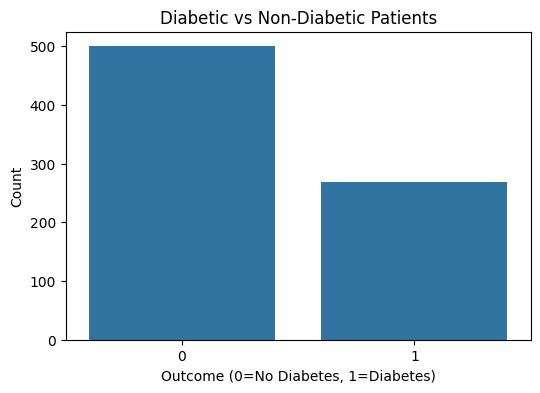

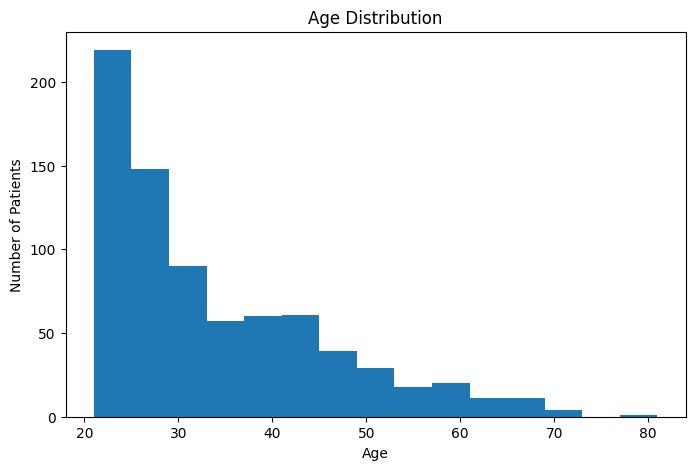

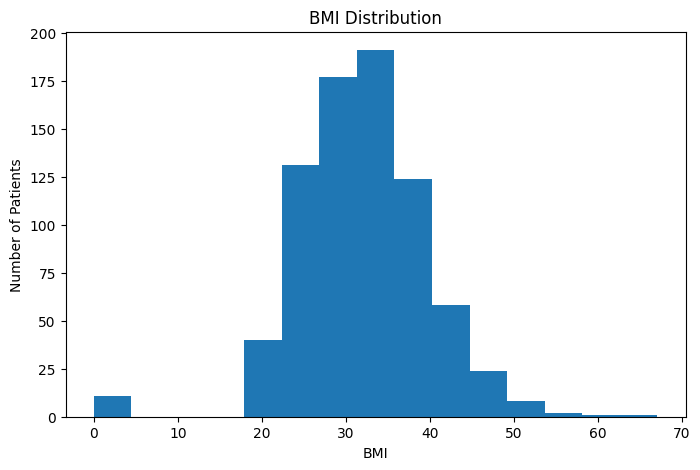

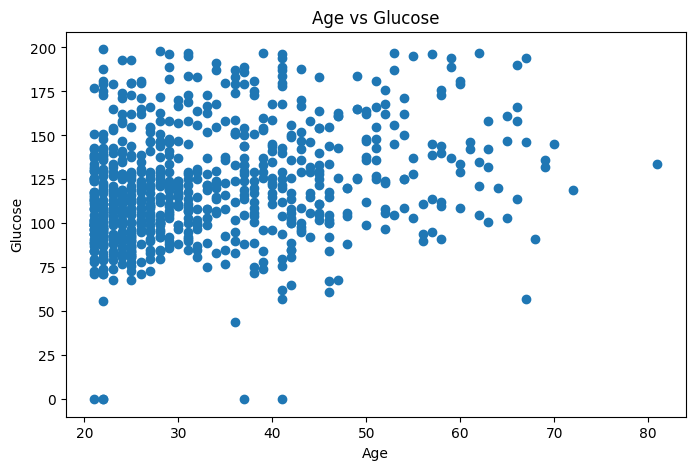

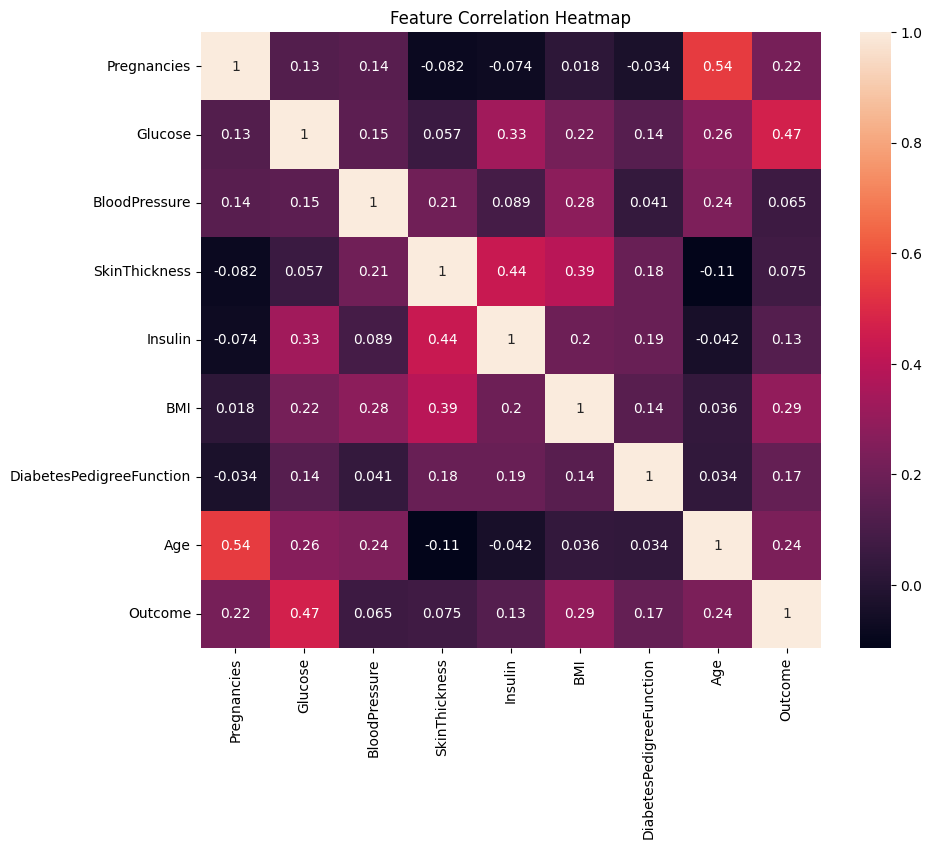

Model Training Completed
Accuracy: 72.08 %


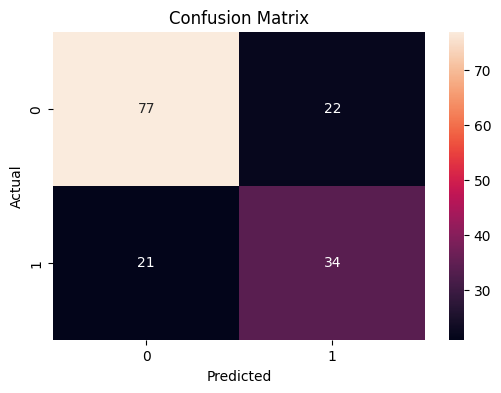

              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



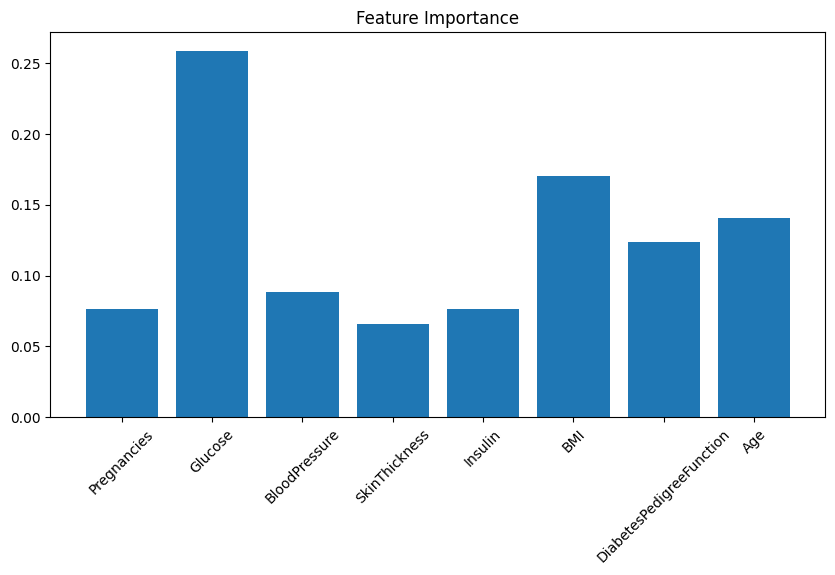

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Patient is NON-DIABETIC
Pregnancies: 3
Glucose: 576
Blood Pressure: 876
Skin Thickness: 233
Insulin: 12
BMI: 13
Diabetes Pedigree Function: 344422
Age: 34


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Prediction: DIABETIC
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


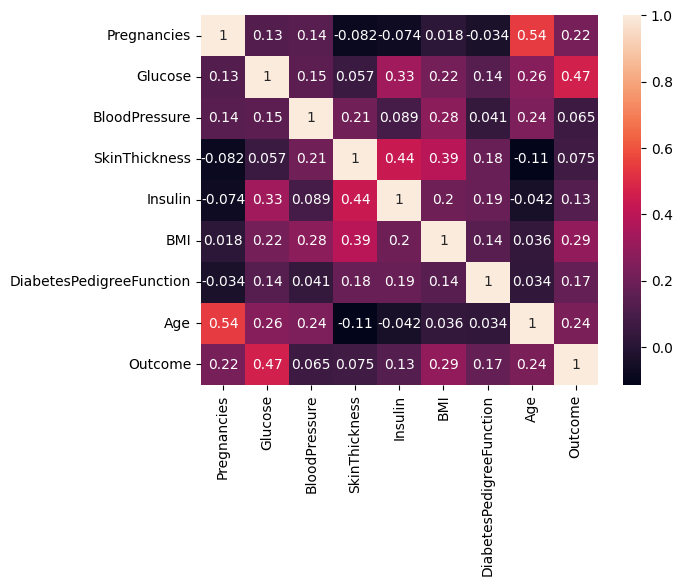

In [7]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

df = pd.read_csv(url, names=columns)

df.to_csv("diabetes.csv", index=False)

print("CSV file created successfully!")
df.head()

!pip install pandas numpy scikit-learn matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

# Corrected line: removed 'names=columns' as the CSV already has a header
df = pd.read_csv('diabetes.csv')

df.head()
print("Dataset Shape:", df.shape)

df.info()

df.describe()
df.isnull().sum()
plt.figure(figsize=(6,4))

sns.countplot(x='Outcome', data=df)

plt.title("Diabetic vs Non-Diabetic Patients")
plt.xlabel("Outcome (0=No Diabetes, 1=Diabetes)")
plt.ylabel("Count")

plt.show()
plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()
plt.figure(figsize=(8,5))

plt.hist(df['BMI'], bins=15)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.show()
plt.figure(figsize=(8,5))

plt.scatter(df['Age'], df['Glucose'])

plt.title("Age vs Glucose")
plt.xlabel("Age")
plt.ylabel("Glucose")

plt.show()
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()
X = df.drop('Outcome', axis=1)

y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy*100,2), "%")
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()
print(classification_report(y_test, predictions))
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))

plt.bar(features, importance)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()
new_patient = [[
    2,      # Pregnancies
    120,    # Glucose
    70,     # Blood Pressure
    20,     # Skin Thickness
    85,     # Insulin
    28.5,   # BMI
    0.35,   # Diabetes Pedigree Function
    30      # Age
]]

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Patient is DIABETIC")
else:
    print("Patient is NON-DIABETIC")

preg = int(input("Pregnancies: "))
glu = float(input("Glucose: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
ins = float(input("Insulin: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = int(input("Age: "))

patient = [[preg, glu, bp, skin, ins, bmi, dpf, age]]

result = model.predict(patient)

if result[0] == 1:
    print("Prediction: DIABETIC")
else:
    print("Prediction: NON-DIABETIC")

df = pd.read_csv("diabetes.csv")

print(df.dtypes)
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()